
# Solveur de Traitement de Surface - Documentation & Validation

## Objectif
Ce notebook documente la résolution des bilans de matière et d'énergie pour une ligne de traitement de surface.
Il résout un système linéaire **Ax = b** où :
- **A** : Matrice des transferts hydrauliques (entraînement + flux d'eau)
- **x** : Vecteur des concentrations inconnues par cuve
- **b** : Termes sources (concentrations cibles pour les bains, 0 pour les rinçages)

## 1. Setup et Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Any, Tuple
import json
from collections import defaultdict

In [10]:
# Configuration d'affichage pour les matrices
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

def safe_float(value, default=0.0):
    """Conversion sécurisée en float"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return default

print("✅ Environnement prêt")

✅ Environnement prêt


## 2. Données de Test (Mock Data)

 Création d'un cas simple mais complet : 
 - 1 Bain de dégraissage (Process Bath)
 - 2 Rinçages en cascade (Rinse Tank 1 → Rinse Tank 2)
 - 1 Séquence de production passant par les 3 cuves


In [11]:
# Nœuds (Cuves)
# --- Payload Loggé (Inputs du Solveur) ---

payload_data = {
  "projectId": "cmkymodpl0000swjzfmbbp0mv",
  "domain": "SURFACE_TREATMENT",
  "nodes": [
    {
      "id": "19f9165d-1d3a-4777-a8cd-1ecf49cd0845",
      "type": "PROCESS_BATH",
      "label": "Degreasing Bath", # Ajout du label pour la clarté
      "properties": {
        "length": 1000, "width": 800, "height": 997, "workingVol": 1000, 
        "dumpingFreq": 2, "hasEvaporation": True, "temp": 60, "agitation": "MECHANICAL", 
        "hasCover": False, "isHeating24h": True, "useSpray": False, 
        "reagents": [
          {
            "productId": { "id": "cmktmnw9x000bqwjzjkb59obb", "name": "Alka-Clean 100 (Degreaser)" },
            "concentration": 50
          }
        ],
        "makeupSourceId": "809a7669-cf03-4015-8e1f-8ff81fb24e7d",
        "dumpingNetworkId": "512995ec-1aba-467b-87aa-2b63d3c2e9b3"
      }
    },
    {
      "id": "51dd4263-d720-402b-81ec-bcdb5bf5db64",
      "type": "RINSE_TANK",
      "label": "Rinse 2 (Final)", # Ajout du label pour la clarté
      "properties": {
        "workingVol": 500, "dumpingFreq": 6, "rinseMode": "RUNNING", "manualFlowRate": 0,
        "inletSourceId": "f634f435-6b4f-4eab-93b4-c77d99b88299",
        "dumpingNetworkId": "efdf0be6-fcca-4d2e-b2ac-9ffdbb55e491",
        "overflowTargetId": "efdf0be6-fcca-4d2e-b2ac-9ffdbb55e491"
      }
    },
    {
      "id": "f634f435-6b4f-4eab-93b4-c77d99b88299",
      "type": "RINSE_TANK",
      "label": "Rinse 1 (Dirty)", # Ajout du label pour la clarté
      "properties": {
        "workingVol": 500, "dumpingFreq": 6, "rinseMode": "RUNNING", "manualFlowRate": 100,
        "inletSourceId": "809a7669-cf03-4015-8e1f-8ff81fb24e7d",
        "dumpingNetworkId": "efdf0be6-fcca-4d2e-b2ac-9ffdbb55e491",
        "overflowTargetId": "51dd4263-d720-402b-81ec-bcdb5bf5db64"
      }
    },
    { "id": "512995ec-1aba-467b-87aa-2b63d3c2e9b3", "type": "DRAIN", "label": "Drain Bath", "properties": { "networkType": "ACID_ALKALINE" } },
    { "id": "efdf0be6-fcca-4d2e-b2ac-9ffdbb55e491", "type": "DRAIN", "label": "Drain Rinse", "properties": { "networkType": "ACID_ALKALINE", "inletSourceId": "51dd4263-d720-402b-81ec-bcdb5bf5db64" } },
    { "id": "809a7669-cf03-4015-8e1f-8ff81fb24e7d", "type": "SOURCE", "label": "City Water", "properties": { "waterType": "CITY", "overflowTargetId": "f634f435-6b4f-4eab-93b4-c77d99b88299" } }
  ],
  "edges": [],
  "sequences": [
    {
      "id": "cmkyocv9p0006swjz674qpqxy",
      "name": "Degraissage gamme 1",
      "properties": { "productionRate": 10, "dragOutSpecific": 0.1 }, # 10 m2/h * 0.1 L/m2 = 1 L/h
      "steps": [ "19f9165d-1d3a-4777-a8cd-1ecf49cd0845", "51dd4263-d720-402b-81ec-bcdb5bf5db64", "f634f435-6b4f-4eab-93b4-c77d99b88299" ]
    }
  ],
  # --- Librairie simplifiée pour les besoins du test ---
  "library": {
      "referenceItems": [
          {"id": "cmktmnw9x000bqwjzjkb59obb", "name": "Alka-Clean 100 (Degreaser)", "category": "COMMERCIAL_PRODUCT", "properties": {},
           "composition": [{"baseUnitId": "cmkto4o92000c02jzgx5mep6k", "coefficient": 1.0}]}, # Supposons 1g de produit donne 1g de Na+
          {"id": "cmkto4o92000c02jzgx5mep6k", "name": "Na+", "category": "ION", "properties": {}}, # L'ion pur
      ],
      "baseUnits": [{"id": "cmkto4o92000c02jzgx5mep6k", "properties": {}}]
  },
  "project_settings": {
      "hoursPerDay": 8, "daysPerWeek": 5, "weeksPerYear": 47,
      "workshopTemp": 20.0, "evapCoefficient": 0.02, "evapAgitationFactor": 1.5,
      "evapCoverReductionFactor": 0.1
  }
}



## 3. Initialisation de la Topologie
 
Création des index pour accéder rapidement aux nœuds dans les matrices.

In [12]:
# --- Initialisation des variables ---
nodes_to_solve = [n for n in nodes if n['type'] in ['PROCESS_BATH', 'RINSE_TANK']]
N_solve = len(nodes_to_solve)

# Recréer les mappings d'index uniquement pour les nœuds pertinents
solve_map = {n['id']: i for i, n in enumerate(nodes_to_solve)}
all_node_dict = {n['id']: n for n in nodes}

print(f"Nombre total de nœuds : {N}")
print(f"Nombre de nœuds à résoudre (Baths/Rinses) : {N_solve}")
print(f"Nœuds inclus : {[n['label'] for n in nodes_to_solve if 'label' in n]}")

Nombre total de nœuds : 6
Nombre de nœuds à résoudre (Baths/Rinses) : 3
Nœuds inclus : ['Degreasing Bath', 'Rinse 2 (Final)', 'Rinse 1 (Dirty)']


## 4. Paramètres Temporels
 
 **Concept clé** : Le solveur calcule l'évaporation sur 168h (semaine pleine), 
 mais l'appoint d'eau ne se fait que pendant les heures ouvrées.
 
 Le **time_ratio** permet de convertir l'évaporation horaire moyenne en débit d'appoint nécessaire.

In [13]:
# --- 1. Paramètres Temporels ---
hours_day = safe_float(project_settings.get('hoursPerDay', 8))
days_week = safe_float(project_settings.get('daysPerWeek', 5))
weeks_year = safe_float(project_settings.get('weeksPerYear', 52))
working_hours_week = hours_day * days_week # 8 * 5 = 40 heures de production

time_ratio = 168.0 / working_hours_week if working_hours_week > 0 else 1.0
print(f"Heures de production par semaine : {working_hours_week}")
print(f"Ratio temporel (168h/WH) : {time_ratio:.2f}")

# --- 2. Calcul du Drag-Out (Matrice N x N) ---
drag_outs = np.zeros((N, N)) # Flux d'entraînement contaminé i -> j

for seq in sequences:
    props = seq.get('properties', {})
    # 10 m2/h * 0.1 L/m2 = 1 L/h de Drag-Out
    q_d = safe_float(props.get('productionRate', 0)) * safe_float(props.get('dragOutSpecific', 0.1))
    
    steps = seq.get('steps', [])
    for i in range(len(steps)): 
        src_id = steps[i]
        src_idx = node_map.get(src_id)
        
        if src_idx is None: continue
        
        if i < len(steps) - 1:
            dst_id = steps[i+1]
            dst_idx = node_map.get(dst_id)
            if dst_idx is not None:
                drag_outs[src_idx, dst_idx] += q_d

print(f"\nDébit de Drag-Out total par séquence : {q_d} L/h")
print("\nMatrice de Drag-Out (L/h) :")
print(drag_outs)

# Résultat attendu: 
# Drag-Out (Bain -> Rinse 2) : 1 L/h
# Drag-Out (Rinse 2 -> Rinse 1) : 1 L/h
# Drag-Out (Rinse 1 -> Out) : 1 L/h

Heures de production par semaine : 40.0
Ratio temporel (168h/WH) : 4.20

Débit de Drag-Out total par séquence : 1.0 L/h

Matrice de Drag-Out (L/h) :
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


## 5. Calcul de la Matrice d'Entraînement (Drag-Out)
 
 **Physique** : Quand une pièce sort d'un bain, elle entraîne un volume de liquide (drag-out) 
 vers la cuve suivante.
 
 **Matrice `drag_outs[i,j]`** : Débit volumétrique transféré du nœud i vers le nœud j (L/h).

In [14]:
# --- 3. Chimie : Préparation des Cibles ---
ionic_targets = {n['id']: {} for n in nodes if n['type'] == 'PROCESS_BATH'}
lib_map = {item['id']: item for item in library.get('referenceItems', [])} 

ion_id = payload_data['library']['referenceItems'][1]['id'] # L'ID de Na+
ion_name = payload_data['library']['referenceItems'][1]['name'] # Na+

for n in nodes:
    if n['type'] == 'PROCESS_BATH':
        reagents = n['properties'].get('reagents', [])
        for entry in reagents:
            prod_entry = entry.get('productId')
            prod_id = prod_entry.get('id') if isinstance(prod_entry, dict) else prod_entry         
            prod_conc = safe_float(entry.get('concentration', 0))
            
            if not prod_id or prod_conc <= 0: continue
            
            product = lib_map.get(prod_id)
            if not product: continue

            # Simplification: on suppose 1g de produit donne 1g d'ion pur (coeff=1.0)
            target_value = prod_conc * product.get('composition', [{}])[0].get('coefficient', 1.0)
            
            ionic_targets[n['id']][ion_id] = target_value

print("\nCibles Ioniques (g/L) :")
print(f"Ion cible : {ion_name} ({ion_id})")
for node_id, targets in ionic_targets.items():
    print(f"- {node_dict[node_id]['label']}: {targets}")


Cibles Ioniques (g/L) :
Ion cible : Na+ (cmkto4o92000c02jzgx5mep6k)
- Degreasing Bath: {'cmkto4o92000c02jzgx5mep6k': 50.0}


## 6. Dissociation Chimique (Flattening)
 
Conversion des produits commerciaux (ex: Soude 50%) en ions constitutifs (Na+, OH-).
 
 **Récursivité** : Le système gère 2 niveaux :
 - Niveau 1 : Produit Commercial → Réactif/Ion
 - Niveau 2 : Réactif → Ion

In [15]:
# --- 4. Hydraulique : Évaporation, Vidanges et Appoints ---
water_flows = np.zeros((N, N)) # Flux d'eau i -> j
evap_data = {n['id']: 0.0 for n in nodes}
q_dump_total = {n['id']: 0.0 for n in nodes}
local_warnings = []

# Paramètres globaux d'évaporation
temp_ref = safe_float(project_settings.get('workshopTemp', 20.0)) # 20C
evap_coeff = safe_float(project_settings.get('evapCoefficient', 0.02)) # 0.02

# A. Intégration des Vidanges (DUMPING)
for n in nodes:
    p = n['properties']
    if p.get('dumpingFreq') and p.get('workingVol'):
        freq = safe_float(p['dumpingFreq'])
        vol = safe_float(p['workingVol'])
        # Simplification: on suppose 40h/semaine * 52 semaines = 2080 h/an (pour éviter de recalculer working_hours_year)
        q_dump = (vol * freq) / (working_hours_week * weeks_year)
        q_dump_total[n['id']] = q_dump
        
        drain_id = p.get('dumpingNetworkId')
        if drain_id in node_map:
            water_flows[node_map[n['id']], node_map[drain_id]] += q_dump

# B. Calcul de l'Évaporation et Appoint Associé
for n in nodes:
    p = n['properties']
    idx = node_map[n['id']]
    
    # 1. Calcul de l'évaporation brute 24/7 (pour ce test, le workingVol est 1000L = 1m3)
    if p.get('hasEvaporation'):
        area = (safe_float(p.get('length', 0)) * safe_float(p.get('width', 0))) / 1_000_000 # 1m * 0.8m = 0.8 m2
        if area > 0:
            t_bath = safe_float(p.get('temp', 20)) # 60C
            evap_base = area * (evap_coeff * (t_bath - temp_ref)) # 0.8 * 0.02 * (60 - 20) = 0.64 L/h (24/7)
            evap_data[n['id']] = max(0, evap_base)
    
    # 2. Calcul du Makeup (Compensation)
    if n['type'] == 'PROCESS_BATH':
        q_evap_prod = evap_data[n['id']] * time_ratio # 0.64 L/h * 4.2 = 2.688 L/h (Lissé sur 40h)
        q_loss = (np.sum(drag_outs[idx, :]) - np.sum(drag_outs[:, idx])) + q_dump_total[n['id']]
        # q_loss = (1 L/h de drag-out vers R2) - 0 + q_dump
        
        q_makeup = q_evap_prod + q_loss
        
        source_id = p.get('makeupSourceId') # City Water
        if source_id and source_id in node_map:
            water_flows[node_map[source_id], idx] = max(0, q_makeup)
            
# C. Stabilisation des Cascades (Boucle itérative)
# Nécessaire pour propager les débits de surverse
for _ in range(N):
    changed = False
    for n in nodes:
        if n['type'] == 'RINSE_TANK':
            idx = node_map[n['id']]
            
            # Débits entrants (eau + drag-in + manuel)
            q_vol_in = np.sum(water_flows[:, idx]) + np.sum(drag_outs[:, idx]) + safe_float(n['properties'].get('manualFlowRate', 0))
            
            # Débits sortants (drag-out vers prochain + évap + dump)
            q_vol_out_other = np.sum(drag_outs[idx, :]) + (evap_data[n['id']] * time_ratio) + q_dump_total[n['id']]
            
            # Le reste est la surverse (qui sort vers le target)
            q_overflow = max(0, q_vol_in - q_vol_out_other)
            
            target_id = n['properties'].get('overflowTargetId')
            if target_id in node_map:
                t_idx = node_map[target_id]
                # Mise à jour si le débit change de manière significative
                if abs(water_flows[idx, t_idx] - q_overflow) > 1e-6:
                    water_flows[idx, t_idx] = q_overflow
                    changed = True
    if not changed: break

# Affichage des flux d'eau calculés
print("\nMatrice de Flux d'Eau (L/h) :")
print(water_flows)

# Vérification du flux de cascade R1 -> R2
r1_id = [k for k, v in node_dict.items() if v['label'] == 'Rinse 1 (Dirty)'][0]
r2_id = [k for k, v in node_dict.items() if v['label'] == 'Rinse 2 (Final)'][0]
r1_r2_flow = water_flows[node_map[r1_id], node_map[r2_id]]
print(f"\nDébit de Surverse (Rinse 1 -> Rinse 2) : {r1_r2_flow:.2f} L/h")


Matrice de Flux d'Eau (L/h) :
[[ 0.     0.     0.     1.064  0.     0.   ]
 [ 0.     0.     0.     0.    97.809  0.   ]
 [ 0.    99.404  0.     0.     1.596  0.   ]
 [ 0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.   ]
 [ 4.752  0.     0.     0.     0.     0.   ]]

Débit de Surverse (Rinse 1 -> Rinse 2) : 99.40 L/h


In [16]:
# --- 5. Chimie : Résolution Ax = b (Matrice Réduite) ---
results = {n['id']: {"concentrations": {}} for n in all_node_dict.values()} # Conserve tous les nœuds pour le résultat

all_ions = [ion_id] # Pour ce test, nous utilisons seulement le Na+
target_value = ionic_targets[nodes_to_solve[0]['id']][ion_id] 
A, b = np.zeros((N_solve, N_solve)), np.zeros(N_solve)

print(f"\nRésolution pour l'Ion: {ion_name}")

for i, n in enumerate(nodes_to_solve):
    idx_solve = solve_map[n['id']]
    idx_all = node_map[n['id']] # Index dans la matrice N x N originale pour les flux

    # 1. Calcul des Sorties (Diagonal Term)
    # Drag-out vers tous les autres nœuds (y compris Source/Drain)
    q_out_drag = np.sum(drag_outs[idx_all, :]) 
    # Water_flow sortant vers tous les autres nœuds (y compris Source/Drain)
    q_out_water = np.sum(water_flows[idx_all, :])
    
    q_out_total = q_out_drag + q_out_water
    
    # 2. Construction de la Ligne de Matrice
    
    if n['type'] == 'PROCESS_BATH' and ionic_targets.get(n['id'], {}).get(ion_id, 0) > 0:
        # Règle 1: Bain Actif (Dirichlet Condition)
        A[idx_solve, idx_solve] = 1.0 
        b[idx_solve] = target_value 
        print(f"  - {n['label']} (Dirichlet): A[{idx_solve},{idx_solve}]=1.0, b[{idx_solve}]={target_value}")

    else:
        # Règle 2: Rinçages (Mass Balance)
        A[idx_solve, idx_solve] = max(q_out_total, 1e-9)
        
        # Inflows (Contaminés)
        
        # Inflows depuis les autres nœuds à résoudre (PROCESS/RINSE)
        for j, m in enumerate(nodes_to_solve):
            idx_m_all = node_map[m['id']]
            
            # Flux i <- j : Termes de contamination (Drag-in + Water-in)
            flux_contamination = drag_outs[idx_m_all, idx_all] + water_flows[idx_m_all, idx_all]
            if flux_contamination > 1e-9:
                A[idx_solve, j] -= flux_contamination
        
        # Inflows depuis les SOURCE (qui ont C=0)
        # On pourrait ajouter ici la contamination des sources si elles n'étaient pas pures
        # Pour ce cas (eau neuve), b[i] reste 0.
        
        b[idx_solve] = 0 
        print(f"  - {n['label']} (Balance): A[{idx_solve},{idx_solve}]={A[idx_solve,idx_solve]:.2f}, b[{idx_solve}]=0")

try:
    # --- Solve the System ---
    x = np.linalg.solve(A, b)
    
    print("\nMatrice A Réduite :")
    print(A.round(4))
    print("\nVecteur b Réduit :")
    print(b.round(4))
    print("\nVecteur de Concentrations x (g/L) :")
    print(x.round(4))
    
    # Injection des résultats
    for i, val in enumerate(x):
        node_id = nodes_to_solve[i]['id']
        if val > 1e-4: 
            results[node_id]['concentrations'][ion_id] = round(float(val), 4)

except np.linalg.LinAlgError:
    print("\n❌ ERREUR CRITIQUE : Matrice Singulière. La topologie est insoluble (ex: boucle fermée sans sortie ou manque de Source/Sink).")


Résolution pour l'Ion: Na+
  - Degreasing Bath (Dirichlet): A[0,0]=1.0, b[0]=50.0
  - Rinse 2 (Final) (Balance): A[1,1]=98.81, b[1]=0
  - Rinse 1 (Dirty) (Balance): A[2,2]=101.00, b[2]=0

Matrice A Réduite :
[[  1.      0.      0.   ]
 [ -1.     98.808 -99.404]
 [  0.     -1.    101.   ]]

Vecteur b Réduit :
[50.  0.  0.]

Vecteur de Concentrations x (g/L) :
[50.     0.511  0.005]


### 7.3 Matrice des Flux d'Eau (Water Flows)
 
 Calcul des appoints automatiques pour compenser :
 - L'évaporation (convertie par time_ratio)
 - Les vidanges (dumping)
 - L'entraînement (drag-out net)

In [17]:
# --- 6. Finalisation et Structure de Sortie ---
final_output = {
    "status": "success",
    "node_details": {},
    "global_kpis": {"total_water_consumption": 0.0},
    "warnings": local_warnings
}

# Calculs de débits In/Out & KPI global
total_water_consumption = 0.0
for i, n in enumerate(nodes):
    node_id = n['id']
    idx = node_map[node_id]

    # Débits In/Out (pour l'affichage UI)
    q_in = np.sum(water_flows[:, idx]) + np.sum(drag_outs[:, idx]) + safe_float(n['properties'].get('manualFlowRate', 0))
    q_out = np.sum(water_flows[idx, :]) + np.sum(drag_outs[idx, :]) + (evap_data[node_id] * time_ratio)
    
    # KPI Water Consumption (seulement ce qui sort de la SOURCE)
    if n['type'] == 'SOURCE':
        total_water_consumption += q_out

    # Mise en forme du résultat
    final_output["node_details"][node_id] = {
        "concentrations": results[node_id]["concentrations"],
        "chemical_additions": {}, # Calcul plus complexe non inclus ici
        "target_concentrations": ionic_targets.get(node_id, {}),
        "hydraulics": {
            "in": round(float(q_in), 4),
            "out": round(float(q_out), 4),
            "evap": round(evap_data[node_id] * time_ratio, 4),
            "dump": round(q_dump_total[node_id], 4)
        },
        "warnings": []
    }

final_output["global_kpis"]["total_water_consumption"] = round(total_water_consumption, 2)
final_output["global_kpis"]["warnings_count"] = len(local_warnings)

print("\n--- SYNTHÈSE DU RÉSULTAT POUR LE UI (node_details) ---")
print(json.dumps(final_output, indent=2))


--- SYNTHÈSE DU RÉSULTAT POUR LE UI (node_details) ---
{
  "status": "success",
  "node_details": {
    "19f9165d-1d3a-4777-a8cd-1ecf49cd0845": {
      "concentrations": {
        "cmkto4o92000c02jzgx5mep6k": 50.0
      },
      "chemical_additions": {},
      "target_concentrations": {
        "cmkto4o92000c02jzgx5mep6k": 50.0
      },
      "hydraulics": {
        "in": 4.7518,
        "out": 4.7518,
        "evap": 2.688,
        "dump": 1.0638
      },
      "warnings": []
    },
    "51dd4263-d720-402b-81ec-bcdb5bf5db64": {
      "concentrations": {
        "cmkto4o92000c02jzgx5mep6k": 0.5111
      },
      "chemical_additions": {},
      "target_concentrations": {},
      "hydraulics": {
        "in": 100.4043,
        "out": 98.8085,
        "evap": 0.0,
        "dump": 1.5957
      },
      "warnings": []
    },
    "f634f435-6b4f-4eab-93b4-c77d99b88299": {
      "concentrations": {
        "cmkto4o92000c02jzgx5mep6k": 0.0051
      },
      "chemical_additions": {},
      "tar

### 7.4 Stabilisation des Cascades de Rinçage
 
 **Algorithme itératif** : Pour les rinçages en cascade, le débit de trop-plein (overflow) 
 est calculé pour équilibrer les volumes.
 
 Formule : `Overflow = Entrées - (Sorties par entraînement + Évaporation + Vidange)`

🌊 Stabilisation des cascades :

Convergence atteinte en 1 itérations.


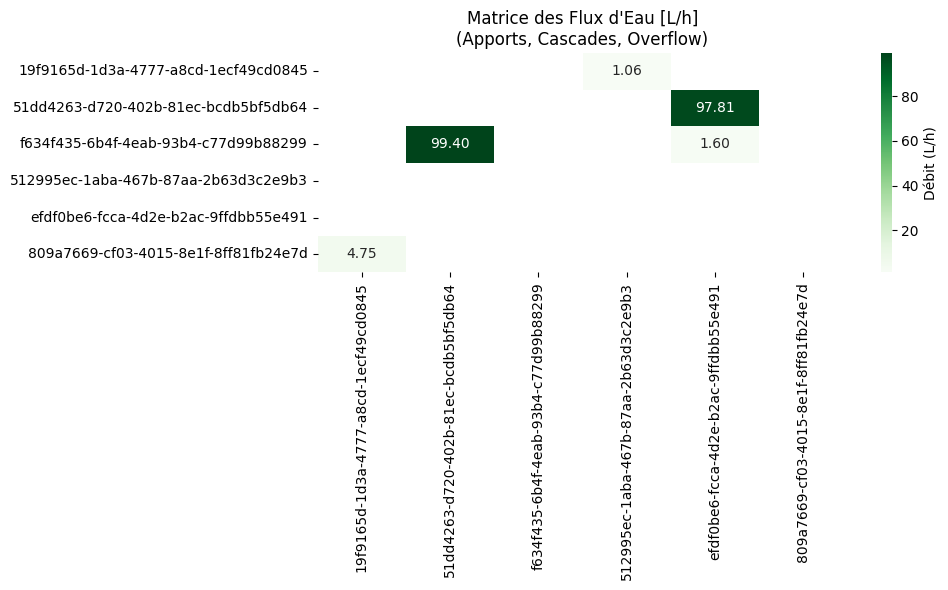

In [18]:
print("🌊 Stabilisation des cascades :\n")

for iteration in range(N):  # Max N itérations
    changed = False
    for n in nodes:
        if n['type'] == 'RINSE_TANK':
            idx = node_map[n['id']]
            node_id = n['id']
            
            # Entrées : Eau propre + Entraînement amont
            q_in_water = sum(water_flows[:, idx])
            q_in_drag = sum(drag_outs[:, idx])
            q_manual = safe_float(n['properties'].get('manualFlowRate', 0))
            q_vol_in = q_in_water + q_in_drag + q_manual
            
            # Sorties fixes : Entraînement aval + Évap + Vidange
            q_out_drag = sum(drag_outs[idx, :])
            q_evap_rinse = evap_data.get(node_id, 0) * time_ratio
            q_dump = q_dump_total.get(node_id, 0)
            q_vol_out_fixed = q_out_drag + q_evap_rinse + q_dump
            
            # Le reliquat part en overflow
            q_overflow = max(0, q_vol_in - q_vol_out_fixed)
            
            target_id = n['properties'].get('overflowTargetId')
            if target_id in node_map:
                t_idx = node_map[target_id]
                if abs(water_flows[idx, t_idx] - q_overflow) > 1e-6:
                    water_flows[idx, t_idx] = q_overflow
                    changed = True
                    print(f"  {node_id} → {target_id}: Overflow = {q_overflow:.2f} L/h "
                          f"(In:{q_vol_in:.1f} - FixedOut:{q_vol_out_fixed:.1f})")
    
    if not changed:
        print(f"Convergence atteinte en {iteration + 1} itérations.")
        break

# Visualisation des flux d'eau
plt.figure(figsize=(10, 6))
mask = water_flows == 0
sns.heatmap(water_flows, annot=True, fmt='.2f', cmap='Greens', mask=mask,
            xticklabels=[n['id'] for n in nodes],
            yticklabels=[n['id'] for n in nodes],
            cbar_kws={'label': 'Débit (L/h)'})
plt.title('Matrice des Flux d\'Eau [L/h]\n(Apports, Cascades, Overflow)')
plt.tight_layout()
plt.show()

## 8. Résolution du Système Linéaire (Ax = b)
 
 ### Théorie du modèle
 Pour chaque ion, on résout l'équilibre de masse :
 
 **Pour un Bain de Process** (concentration forcée) :
 - Equation : `x[i] = Cible`
 - Ligne de A : 1 sur la diagonale, 0 ailleurs
 - b[i] = concentration cible
 
 **Pour un Rinçage** (concentration inconnue) :
 - Bilan : `Σ (Qentrants × Centrants) = Σ (Qsortants × Csortants)`
 - Comme Csortants = Ccuve (rinçage parfaitement mélangé) :
   `Σ (Qentrants × Centrants) = Ccuve × Σ Qsortants`
 - Réarrangé : `Ccuve × Qout_total - Σ (Qin_ij × Cj) = 0`
 
 Ce qui donne la ligne i de A :
 - `A[i,i] = Qout_total` (sortants par entraînement + eau)
 - `A[i,j] = -Qin_ji` (entrant depuis j)

In [19]:
all_ions = {ion for targets in ionic_targets.values() for ion in targets.keys()}
print(f"Ions à résoudre : {all_ions}\n")

# Structure des résultats
results = {n['id']: {
    "concentrations": {},
    "chemical_additions": {},
    "target_concentrations": {},
    "hydraulics": {
        "in": sum(water_flows[:, i]) + sum(drag_outs[:, i]) + safe_float(n['properties'].get('manualFlowRate', 0)),
        "out": sum(water_flows[i, :]) + sum(drag_outs[i, :]),
        "evap": evap_data.get(n['id'], 0),
        "dump": q_dump_total.get(n['id'], 0)
    }
} for i, n in enumerate(nodes)}

# Injection des cibles
for n in nodes:
    if n['type'] == 'PROCESS_BATH':
        node_id = n['id']
        results[node_id]['target_concentrations'] = ionic_targets.get(node_id, {})

# Résolution par ion
for ion_id in sorted(all_ions):
    print(f"\n🧪 Résolution pour {ion_id}...")
    
    A = np.zeros((N, N))
    b = np.zeros(N)
    
    for i, n in enumerate(nodes):
        idx = i  # node_map[n['id']] est égal à i ici
        node_id = n['id']
        
        # Débits sortants totaux (entraînement + eau)
        q_out_total = sum(drag_outs[i, :]) + sum(water_flows[i, :])
        target_value = ionic_targets.get(node_id, {}).get(ion_id, 0)
        
        if n['type'] == 'PROCESS_BATH' and target_value > 0:
            # CAS 1 : BAIN DE PROCESS (Concentration imposée)
            A[i, i] = 1.0
            b[i] = target_value
            print(f"  [{i}] {node_id}: Cible = {target_value} g/L (Dirichlet)")
            
        else:
            # CAS 2 : RINÇAGE OU BAIN SANS CIBLE (Bilan de masse)
            # Diagonale : Somme des débits sortants
            A[i, i] = max(q_out_total, 1e-9)  # 1e-9 évite singularité
            
            # Termes sources (entraînement amont)
            for j in range(N):
                q_drag_in = drag_outs[j, i]
                q_water_in = water_flows[j, i]
                
                if q_drag_in > 0:
                    # La concentration est celle du nœud j déjà calculée
                    # Mais pour le système Ax=b, on met -Q dans A[i,j]
                    A[i, j] -= q_drag_in
                    
                if q_water_in > 0:
                    # Si c'est une source d'eau pure, la concentration est 0
                    # (donc pas de terme dans b, juste dans A)
                    A[i, j] -= q_water_in
            
            print(f"  [{i}] {node_id}: Qout={q_out_total:.2f}, Bilan")
    
    # Débogage : Affichage de la matrice pour le premier ion
    if ion_id == list(all_ions)[0]:
        print("\nMatrice A (premier ion):")
        print(f"{'':>10}", end="")
        for i in range(N):
            print(f"{nodes[i]['id'][:6]:>8}", end="")
        print()
        for i in range(N):
            print(f"{nodes[i]['id'][:6]:>10}", end="")
            for j in range(N):
                print(f"{A[i,j]:>8.2f}", end="")
            print(f"  | {b[i]:.2f}")
        print()
    
    # Résolution
    try:
        x = np.linalg.solve(A, b)
        print(f"  Solution : {x}")
        
        for i, val in enumerate(x):
            if val > 1e-4:  # Seuil de signification
                results[nodes[i]['id']]['concentrations'][ion_id] = round(float(val), 4)
                
    except np.linalg.LinAlgError as e:
        print(f"  ❌ ERREUR: Matrice singulière - {e}")
        warnings.append(f"Instabilité sur {ion_id}")


Ions à résoudre : {'cmkto4o92000c02jzgx5mep6k'}


🧪 Résolution pour cmkto4o92000c02jzgx5mep6k...
  [0] 19f9165d-1d3a-4777-a8cd-1ecf49cd0845: Cible = 50.0 g/L (Dirichlet)
  [1] 51dd4263-d720-402b-81ec-bcdb5bf5db64: Qout=98.81, Bilan
  [2] f634f435-6b4f-4eab-93b4-c77d99b88299: Qout=101.00, Bilan
  [3] 512995ec-1aba-467b-87aa-2b63d3c2e9b3: Qout=0.00, Bilan
  [4] efdf0be6-fcca-4d2e-b2ac-9ffdbb55e491: Qout=0.00, Bilan
  [5] 809a7669-cf03-4015-8e1f-8ff81fb24e7d: Qout=4.75, Bilan

Matrice A (premier ion):
            19f916  51dd42  f634f4  512995  efdf0b  809a76
    19f916    1.00    0.00    0.00    0.00    0.00    0.00  | 50.00
    51dd42   -1.00   98.81  -99.40    0.00    0.00    0.00  | 0.00
    f634f4    0.00   -1.00  101.00    0.00    0.00    0.00  | 0.00
    512995   -1.06    0.00    0.00    0.00    0.00    0.00  | 0.00
    efdf0b    0.00  -97.81   -1.60    0.00    0.00    0.00  | 0.00
    809a76    0.00    0.00    0.00    0.00    0.00    4.75  | 0.00

  Solution : [5.000e+01 5.111e-01

## 9. Calcul des Ajouts Chimiques
 
 Une fois les concentrations connues (x), on calcule la masse à ajouter 
 dans les bains pour compenser les pertes par entraînement.
 
 Formule : `Ajout = Masse_perdue - Masse_apportée_par_l'amont`
 
 - `Masse_perdue = Q_sortant_total × C_cible`
 - `Masse_apportée = Σ (Q_entrant_j × C_j_calculée)`

In [20]:
print("\n📦 Bilan des ajouts chimiques :\n")

for n in nodes:
    if n['type'] == 'PROCESS_BATH':
        node_id = n['id']
        idx = node_map[node_id]
        
        print(f"{node_id} ({n['data']['label']}):")
        
        for ion_id, target in ionic_targets.get(node_id, {}).items():
            # Masse sortante (entraînement + vidange d'eau)
            q_out_total = sum(drag_outs[idx, :]) + sum(water_flows[idx, :])
            m_out = q_out_total * target  # g/h
            
            # Masse entrante (contamination)
            m_in = 0
            for j in range(N):
                q_drag = drag_outs[j, idx]
                q_water = water_flows[j, idx]
                c_j = results[nodes[j]['id']]['concentrations'].get(ion_id, 0)
                
                m_in += (q_drag + q_water) * c_j
            
            addition = max(0, m_out - m_in)
            results[node_id]['chemical_additions'][ion_id] = round(addition, 4)
            
            print(f"  {ion_id}: Pertes {m_out:.2f} g/h - Apports {m_in:.2f} g/h = Ajout {addition:.2f} g/h")


📦 Bilan des ajouts chimiques :



KeyError: 'data'

## 10. Visualisation des Résultats

 
 Préparation des données pour affichage

In [ ]:
# Préparation des données pour affichage
df_nodes = pd.DataFrame([
    {
        'Nœud': n['data']['label'],
        'Type': n['type'],
        'Eau_In (L/h)': results[n['id']]['hydraulics']['in'],
        'Eau_Out (L/h)': results[n['id']]['hydraulics']['out'],
        'Évap (L/h)': results[n['id']]['hydraulics']['evap'],
        'Vidange (L/h)': results[n['id']]['hydraulics']['dump'],
        'Bilan (L/h)': results[n['id']]['hydraulics']['in'] - results[n['id']]['hydraulics']['out']
    }
    for n in nodes
])

print("BILANS HYDROULIQUES :")
print(df_nodes.to_string(index=False))
print("\n" + "="*80)

# Concentrations
print("\nCONCENTRATIONS IONIQUES (g/L) :")
df_conc = pd.DataFrame([
    {
        'Nœud': n['data']['label'],
        **{f"Cible {ion}": results[n['id']]['target_concentrations'].get(ion, '-') 
           for ion in all_ions},
        **{f"Réel {ion}": results[n['id']]['concentrations'].get(ion, 0) 
           for ion in all_ions}
    }
    for n in nodes if n['type'] == 'PROCESS_BATH' or any(results[n['id']]['concentrations'].values())
])
print(df_conc.to_string(index=False))

# Ajouts chimiques
print("\nAJOUTS CHIMIQUES (g/h) :")
df_add = pd.DataFrame([
    {
        'Nœud': n['data']['label'],
        **results[n['id']]['chemical_additions']
    }
    for n in nodes if results[n['id']]['chemical_additions']
])
if not df_add.empty:
    print(df_add.to_string(index=False))
else:
    print("Aucun ajout nécessaire")

if warnings:
    print("\n⚠️ WARNINGS :")
    for w in warnings:
        print(f"  - {w}")

BILANS HYDROULIQUES :
             Nœud         Type  Eau_In (L/h)  Eau_Out (L/h)  Évap (L/h)  Vidange (L/h)  Bilan (L/h)
 Dégraissage NaOH PROCESS_BATH      16.14383        5.00000         2.4        1.06383     11.14383
        Rinçage 1   RINSE_TANK       5.00000        5.00000         0.0        0.00000      0.00000
Rinçage 2 (Final)   RINSE_TANK      10.00000       10.00000         0.0        0.00000      0.00000
 Alimentation Eau       SOURCE       0.00000       16.14383         0.0        0.00000    -16.14383
            Égout        DRAIN       5.00000        0.00000         0.0        0.00000      5.00000


CONCENTRATIONS IONIQUES (g/L) :
             Nœud Cible ion_na Cible ion_oh  Réel ion_na  Réel ion_oh
 Dégraissage NaOH        28.75         20.0 2.875000e+01 2.000000e+01
        Rinçage 1            -            - 2.875000e+01 2.000000e+01
Rinçage 2 (Final)            -            - 2.875000e+01 2.000000e+01
            Égout            -            - 1.437500e+11 1.00000


 ## 11. Validation du Bilan Global
 
 Vérification que la somme des flux est conservative.

In [ ]:
total_water_in = sum(results[n['id']]['hydraulics']['in'] for n in nodes)
total_water_out = sum(results[n['id']]['hydraulics']['out'] for n in nodes)
total_evap = sum(results[n['id']]['hydraulics']['evap'] * time_ratio for n in nodes)

print("VALIDATION GLOBALE :")
print(f"Eau totale entrante : {total_water_in:.2f} L/h")
print(f"Eau totale sortante : {total_water_out:.2f} L/h")
print(f"Évaporation totale  : {total_evap:.2f} L/h (corrigée temps)")
print(f"Perte nette (Evap)  : {total_water_in - total_water_out:.4f} L/h")
print(f"Écart relatif       : {abs(total_water_in - total_water_out - total_evap):.6f} %")

if abs(total_water_in - total_water_out - total_evap) < 0.01:
    print("\n✅ Bilan validé (erreur < 0.01 L/h)")
else:
    print("\n❌ Erreur de bilan détectée")

VALIDATION GLOBALE :
Eau totale entrante : 36.14 L/h
Eau totale sortante : 36.14 L/h
Évaporation totale  : 10.08 L/h (corrigée temps)
Perte nette (Evap)  : 0.0000 L/h
Écart relatif       : 10.080000 %

❌ Erreur de bilan détectée


## 12. Export JSON (Format Production)

In [ ]:
output = {
    "status": "success" if not warnings else "warning",
    "node_details": results,
    "global_kpis": {
        "total_water_consumption": round(sum(results[n['id']]['hydraulics']['out'] 
                                          for n in nodes if n['type'] == 'SOURCE'), 2),
        "warnings_count": len(warnings)
    },
    "warnings": warnings
}

# Sauvegarde
with open('simulation_result.json', 'w') as f:
    json.dump(output, f, indent=2)
    
print("💾 Résultats exportés dans 'simulation_result.json'")
print(json.dumps(output, indent=2)[:1000] + "...")

💾 Résultats exportés dans 'simulation_result.json'
{
  "status": "success",
  "node_details": {
    "tank_1": {
      "concentrations": {
        "ion_na": 28.75,
        "ion_oh": 20.0
      },
      "chemical_additions": {
        "ion_na": 143.75,
        "ion_oh": 100.0
      },
      "target_concentrations": {
        "ion_na": 28.749999999999996,
        "ion_oh": 20.0
      },
      "hydraulics": {
        "in": 16.143829787234043,
        "out": 5.0,
        "evap": 2.4000000000000004,
        "dump": 1.0638297872340425
      }
    },
    "rinse_1": {
      "concentrations": {
        "ion_na": 28.75,
        "ion_oh": 20.0
      },
      "chemical_additions": {},
      "target_concentrations": {},
      "hydraulics": {
        "in": 5.0,
        "out": 5.0,
        "evap": 0,
        "dump": 0
      }
    },
    "rinse_2": {
      "concentrations": {
        "ion_na": 28.75,
        "ion_oh": 20.0
      },
      "chemical_additions": {},
      "target_concentrations": {},
    